<a href="https://colab.research.google.com/github/dannyycwang/HUSPM-SHAP/blob/main/HUSPM_SHAP_WS50_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import ast

from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


# 加载数据
# df = pd.read_csv('your_data.csv')  # 替换为你的文件路径
df = pd.read_csv('sampled_dataset.csv')

# 将轨迹字符串转换为列表
df['trajectory'] = df['trajectory'].apply(ast.literal_eval)

# 固定序列长度 (早期窗口)
early_window = 5
X = pad_sequences(df['trajectory'], maxlen=early_window, padding='post')

# 目标变量
y = df['Churn'].values
y = to_categorical(y)  # 转换为分类格式

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建模型
#model = Sequential()
#model.add(Embedding(input_dim=100, output_dim=20, input_length=early_window))  # 调整 input_dim
#model.add(LSTM(50, return_sequences=False))
#model.add(Dense(2, activation='softmax'))

# 编译模型
#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model = Sequential()
model.add(Embedding(input_dim=200, output_dim=40, input_length=early_window))  # 增加 input_dim 和 output_dim
model.add(LSTM(100, return_sequences=True))  # 增加 LSTM 单元
model.add(Dropout(0.2))  # 添加 Dropout
model.add(BatchNormalization())  # 添加 BatchNormalization
model.add(LSTM(50, return_sequences=False))
model.add(Dense(2, activation='softmax'))

# 编译模型
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 早停
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

# 训练模型，包括早停回调
history = model.fit(X_train, y_train, epochs=50, validation_split=0.1, callbacks=[early_stopping])


# 测试模型
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy:.4f}')

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


197/197 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.7821 - loss: 0.4374 - val_accuracy: 0.7686 - val_loss: 0.5617
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8244 - loss: 0.3565 - val_accuracy: 0.8343 - val_loss: 0.4046
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8242 - loss: 0.3531 - val_accuracy: 0.8371 - val_loss: 0.3320
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8272 - loss: 0.3459 - val_accuracy: 0.8400 - val_loss: 0.3240
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8239 - loss: 0.3450 - val_accuracy: 0.8371 - val_loss: 0.3258
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8213 - loss: 0.3462 - val_accuracy: 0.8343 - val_loss: 0.3304
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8295 - loss: 0.3378 - val_accuracy: 0.8386 - val_loss: 0.3205
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8210 - loss: 0.3449 - val_accuracy: 0.8

In [ ]:
import tensorflow as tf
print(tf.__version__)


2.15.0


In [ ]:
# 调整模型结构
model = Sequential()
model.add(Embedding(input_dim=200, output_dim=40, input_length=early_window))  # 增加 input_dim 和 output_dim
model.add(LSTM(100, return_sequences=True))  # 增加 LSTM 单元
model.add(Dropout(0.2))  # 添加 Dropout
model.add(BatchNormalization())  # 添加 BatchNormalization
model.add(LSTM(50, return_sequences=False))
model.add(Dense(2, activation='softmax'))

# 编译模型
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 早停
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

# 训练模型，包括早停回调
history = model.fit(X_train, y_train, epochs=50, validation_split=0.1, callbacks=[early_stopping])

Epoch 1/50
197/197 [==============================] - 9s 19ms/step - loss: 0.3926 - accuracy: 0.8062 - val_loss: 0.5889 - val_accuracy: 0.8314
Epoch 2/50
197/197 [==============================] - 3s 14ms/step - loss: 0.3534 - accuracy: 0.8195 - val_loss: 0.4165 - val_accuracy: 0.8357
Epoch 3/50
197/197 [==============================] - 2s 12ms/step - loss: 0.3490 - accuracy: 0.8263 - val_loss: 0.3366 - val_accuracy: 0.8371
Epoch 4/50
197/197 [==============================] - 2s 12ms/step - loss: 0.3458 - accuracy: 0.8256 - val_loss: 0.3268 - val_accuracy: 0.8343
Epoch 5/50
197/197 [==============================] - 2s 11ms/step - loss: 0.3445 - accuracy: 0.8251 - val_loss: 0.3302 - val_accuracy: 0.8371
Epoch 6/50
197/197 [==============================] - 3s 14ms/step - loss: 0.3423 - accuracy: 0.8237 - val_loss: 0.3284 - val_accuracy: 0.8343
Epoch 7/50
197/197 [==============================] - 3s 15ms/step - loss: 0.3392 - accuracy: 0.8238 - val_loss: 0.3251 - val_accuracy: 0.8371

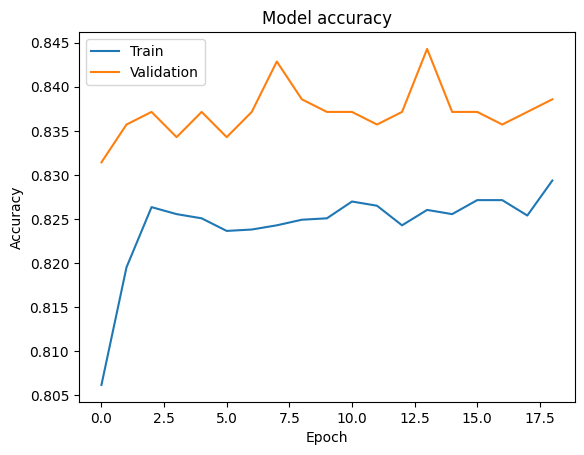

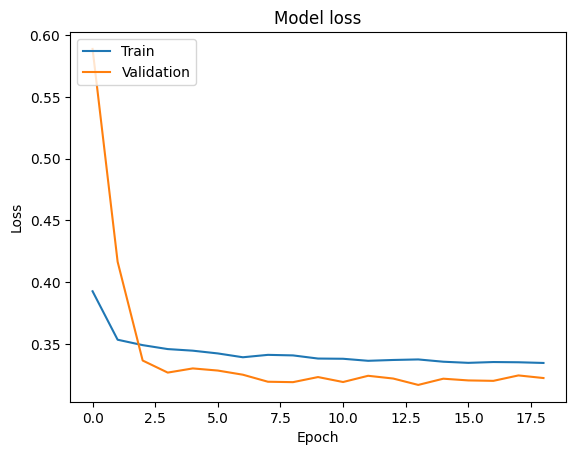

In [ ]:
# Plotting training & validation accuracy values
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

94/94 [==============================] - 2s 6ms/step


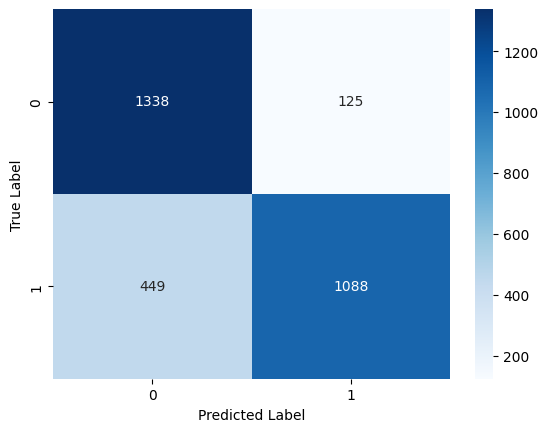

              precision    recall  f1-score   support

           0       0.75      0.91      0.82      1463
           1       0.90      0.71      0.79      1537

    accuracy                           0.81      3000
   macro avg       0.82      0.81      0.81      3000
weighted avg       0.82      0.81      0.81      3000



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict classes using the testing set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report, which includes precision, recall, and F1-score
report = classification_report(y_true, y_pred_classes)
print(report)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve, auc

# 假设 y_true 和 y_pred_classes 是您的真实标签和预测标签
# y_true = [Your true labels]
# y_pred_classes = [Your predicted labels]
y_pred_probs = model.predict(X_test)  # 模型预测的概率

# 由于 y_pred_probs 是一个形状为 (n_samples, 2) 的数组，我们需要选取代表正类概率的列
y_pred_probs = y_pred_probs[:, 1]  # 选择正类（索引为 1）的概率

# 计算度量指标
precision = precision_score(y_true, y_pred_classes)
recall = recall_score(y_true, y_pred_classes)
f1 = f1_score(y_true, y_pred_classes)
mcc = matthews_corrcoef(y_true, y_pred_classes)
accuracy = accuracy_score(y_true, y_pred_classes)
auc_score = roc_auc_score(y_true, y_pred_probs)  # 使用正类的概率计算 AUC

# 计算 PR AUC
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_probs)
pr_auc = auc(recall_vals, precision_vals)

# 打印度量指标
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print(f"PR AUC: {pr_auc:.4f}")




94/94 [==============================] - 1s 5ms/step
Precision: 0.8961
Recall: 0.7072
F1 Score: 0.7905
Matthews Correlation Coefficient: 0.6326
Accuracy: 0.8080
AUC: 0.9129
PR AUC: 0.9255


In [ ]:
model.save('model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


AUC: 0.9129


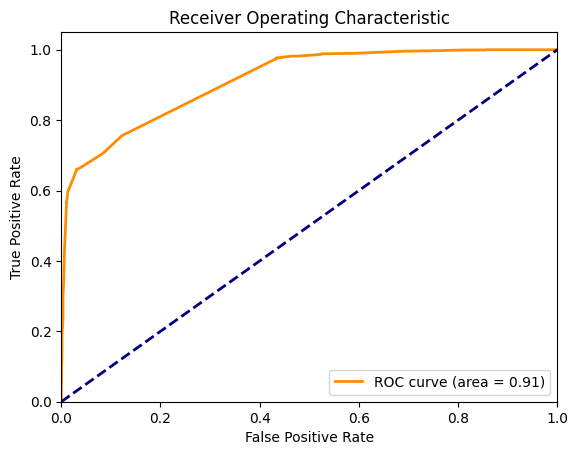

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# 假设 y_true 是您的真实标签和 y_pred_probs 是模型预测的概率
# 例如：y_true = [0, 1, 1, 0, 1] 和 y_pred_probs = [0.1, 0.9, 0.8, 0.3, 0.7]

# 计算AUC
auc = roc_auc_score(y_true, y_pred_probs)
print(f"AUC: {auc:.4f}")

# 计算ROC曲线的坐标
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# 绘制ROC曲线
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()



In [ ]:
!pip install --upgrade shap tensorflow keras

In [ ]:
import shap

# 使用训练数据的一部分来计算 SHAP 值
data_for_shap = X_train[:500]  # 选取前 1000 个样本

# 创建 KernelExplainer
explainer = shap.KernelExplainer(model.predict, data_for_shap)

# 计算 SHAP 值
shap_values = explainer.shap_values(data_for_shap)

# 绘制 SHAP 值的总结图
shap.summary_plot(shap_values, data_for_shap)



16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
469/469 ━━━━━

In [ ]:
import pandas as pd

columns = ['F1','F2','F3','F4','F5']
data = pd.DataFrame(X_train[:500],columns=columns)

# 选择正类的 SHAP 值（假设是列表中的第二个数组）
shap_values_positive_class = shap_values[1]

# 将正类的 SHAP 值转换为 DataFrame
shap_df = pd.DataFrame(shap_values_positive_class, columns=['SHAP F1', 'SHAP F2', 'SHAP F3', 'SHAP F4', 'SHAP F5'])

# 假设 data 是包含原始特徵的 DataFrame
# 合併原始數據和 SHAP 值
combined_df = pd.concat([data, shap_df], axis=1)

# 保存合併後的 DataFrame 到 CSV 文件
combined_df.to_csv('combined_data_shap.csv', index=False)


combined_df

ValueError: Shape of passed values is (5, 2), indices imply (5, 5)

In [ ]:
print(combined_df.columns)

NameError: name 'combined_df' is not defined

In [ ]:
# 转换数据表为所需格式的 transactions
transactions = []
for _, row in combined_df.iterrows():
    transaction = []
    for i in range(1, 6):
        feature = str(int(row[f'F{i}']))  # 將特徵值轉換為整數然後轉為字符串
        shap_value = row[f'SHAP F{i}']
        transaction.append((feature, shap_value))
    transactions.append(transaction)

transactions

[[('2', 0.03079157498390335),
  ('1', 0.004392873566644244),
  ('3', -0.29591136390897244),
  ('1', -0.1117283304817511),
  ('1', -0.09065971541842444)],
 [('1', 0.012790566792169),
  ('1', 0.03145557442020293),
  ('2', 0.3416313960082685),
  ('1', -0.009467610788299607),
  ('1', -0.03090958688656459)],
 [('1', 0.007041716254673516),
  ('1', 0.011191201956524281),
  ('1', -0.00043348094738653096),
  ('1', -0.055797254594462664),
  ('1', -0.06026468196405703)],
 [('2', 0.03723089078630643),
  ('1', 0.03144800355660895),
  ('2', 0.1645169190564522),
  ('1', 0.006311948599011736),
  ('2', 0.2533539156859772)],
 [('1', 0.0018637043610679456),
  ('1', 0.007069036440505071),
  ('3', -0.269371612812499),
  ('1', -0.11179358553307525),
  ('1', -0.09120573225263551)],
 [('2', 0.06547610491696527),
  ('2', 0.09351203865550224),
  ('1', -0.007342693843296984),
  ('3', -0.41148165113575796),
  ('1', -0.0775932878106445)],
 [('1', 0.0158650748405219),
  ('2', 0.07483297622789285),
  ('1', 0.0315205

In [ ]:
# 計算給定序列在單個交易中的實用性
def utility_of_sequence_in_transaction(sequence, transaction):
    utility = 0
    for item in sequence:
        for trans_item, item_utility in transaction:
            if item == trans_item:
                utility += item_utility
                break
    return utility

# 檢查序列是否按順序出現在交易中
def is_sequence_in_transaction(sequence, transaction):
    if not sequence:
        return False
    seq_index = 0
    for trans_item, _ in transaction:
        if trans_item == sequence[seq_index]:
            seq_index += 1
            if seq_index == len(sequence):
                return True
    return False

# 計算序列的總實用性
def calculate_total_utility(sequence, transactions):
    total_utility = 0
    for transaction in transactions:
        if is_sequence_in_transaction(sequence, transaction):
            total_utility += utility_of_sequence_in_transaction(sequence, transaction)
    return total_utility

# 生成所有可能的項目序列
def generate_sequences(items):
    if not items:
        return []
    sequences = [[item] for item in items]
    for i in range(len(items)):
        for subsequence in generate_sequences(items[i + 1:]):
            sequences.append([items[i]] + subsequence)
    return sequences

# 找出具有最高實用性的序列
def find_highest_utility_sequence(transactions):
    items = set()
    for transaction in transactions:
        for item, _ in transaction:
            items.add(item)

    sequences = generate_sequences(list(items))
    highest_utility = 0
    best_sequence = None
    for sequence in sequences:
        utility = calculate_total_utility(sequence, transactions)
        if utility > highest_utility:
            highest_utility = utility
            best_sequence = sequence

    return best_sequence, highest_utility

# 找到最高實用性的序列
best_sequence, highest_utility = find_highest_utility_sequence(transactions)

# 輸出結果
best_sequence, highest_utility

NameError: name 'transactions' is not defined

In [ ]:
# 修改代碼以找出具有最高實用性的前K個序列

def find_top_k_utility_sequences(transactions, k):
    items = set()
    for transaction in transactions:
        for item, _ in transaction:
            items.add(item)

    sequences = generate_sequences(list(items))
    sequence_utilities = []
    for sequence in sequences:
        utility = calculate_total_utility(sequence, transactions)
        sequence_utilities.append((sequence, utility))

    # 根據實用性值進行降序排序並取前K個
    top_k_sequences = sorted(sequence_utilities, key=lambda x: x[1], reverse=True)[:k]
    return top_k_sequences

# 找到最高實用性的前K個序列
k = 20  # 您可以修改這個值來改變取前多少個序列
top_k_sequences = find_top_k_utility_sequences(transactions, k)

# 輸出結果
top_k_sequences

[(['2'], 38.17158675534848),
 (['2', '1'], 36.925313450283056),
 (['1'], 3.742380176630847),
 (['2', '4'], 0),
 (['2', '1', '4'], 0),
 (['2', '1', '3', '4'], 0),
 (['2', '3', '4'], 0),
 (['1', '3', '4'], 0),
 (['3', '4'], 0),
 (['1', '4'], -3.87653562285746),
 (['4'], -6.72003845782889),
 (['2', '1', '3'], -8.02586594151142),
 (['2', '3'], -15.050848229685007),
 (['1', '3'], -21.679352600291566),
 (['3'], -28.361543136996612)]

In [ ]:
import pandas as pd
import numpy as np
import ast
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# 加载数据
df = pd.read_csv('sampled_dataset.csv')
pool_df = pd.read_csv('remaining_dataset.csv')  # 加载数据池

# 将轨迹字符串转换为列表
df['trajectory'] = df['trajectory'].apply(ast.literal_eval)
pool_df['trajectory'] = pool_df['trajectory'].apply(ast.literal_eval)

# 固定序列长度 (早期窗口)
early_window = 5
X = pad_sequences(df['trajectory'], maxlen=early_window, padding='post')
y = to_categorical(df['Churn'].values)  # 转换为分类格式

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Active Learning 循环
n_iterations = 6
n_samples = 1000

# 创建新模型（或者您也可以重用旧模型）
#model = Sequential()
#model.add(Embedding(input_dim=100, output_dim=20, input_length=early_window))
#model.add(LSTM(50, return_sequences=False))
#model.add(Dense(2, activation='softmax'))
#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#model.fit(X_train, y_train, epochs=30, validation_split=0.1)
for iteration in range(n_iterations):
    # 随机选择数据池中的样本
    sample_indices = np.random.choice(pool_df.index, n_samples, replace=False)
    sample_df = pool_df.loc[sample_indices]
    pool_df = pool_df.drop(sample_indices)

    # 准备新增数据
    X_new = pad_sequences(sample_df['trajectory'], maxlen=early_window, padding='post')
    y_new = to_categorical(sample_df['Churn'].values)

    # 更新训练集
    X_train = np.concatenate((X_train, X_new))
    y_train = np.concatenate((y_train, y_new))


    # 训练模型
    model = Sequential()
    model.add(Embedding(input_dim=200, output_dim=40, input_length=early_window))  # 增加 input_dim 和 output_dim
    model.add(LSTM(100, return_sequences=True))  # 增加 LSTM 单元
    model.add(Dropout(0.2))  # 添加 Dropout
    model.add(BatchNormalization())  # 添加 BatchNormalization
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(2, activation='softmax'))

# 编译模型
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 早停
    early_stopping = EarlyStopping(monitor='val_loss', patience=5)

# 训练模型，包括早停回调
    history = model.fit(X_train, y_train, epochs=50, validation_split=0.1, callbacks=[early_stopping])

    # 测试模型
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f'Iteration {iteration+1}, Test Accuracy: {accuracy:.4f}')


Epoch 1/50
225/225 [==============================] - 7s 15ms/step - loss: 0.3833 - accuracy: 0.8056 - val_loss: 0.5697 - val_accuracy: 0.7113
Epoch 2/50
225/225 [==============================] - 3s 12ms/step - loss: 0.3513 - accuracy: 0.8206 - val_loss: 0.4615 - val_accuracy: 0.6525
Epoch 3/50
225/225 [==============================] - 3s 14ms/step - loss: 0.3451 - accuracy: 0.8235 - val_loss: 0.3849 - val_accuracy: 0.7138
Epoch 4/50
225/225 [==============================] - 3s 12ms/step - loss: 0.3461 - accuracy: 0.8232 - val_loss: 0.4251 - val_accuracy: 0.7138
Epoch 5/50
225/225 [==============================] - 2s 11ms/step - loss: 0.3439 - accuracy: 0.8217 - val_loss: 0.3766 - val_accuracy: 0.7138
Epoch 6/50
225/225 [==============================] - 2s 10ms/step - loss: 0.3418 - accuracy: 0.8250 - val_loss: 0.3410 - val_accuracy: 0.7138
Epoch 7/50
225/225 [==============================] - 3s 13ms/step - loss: 0.3402 - accuracy: 0.8251 - val_loss: 0.3452 - val_accuracy: 0.7150

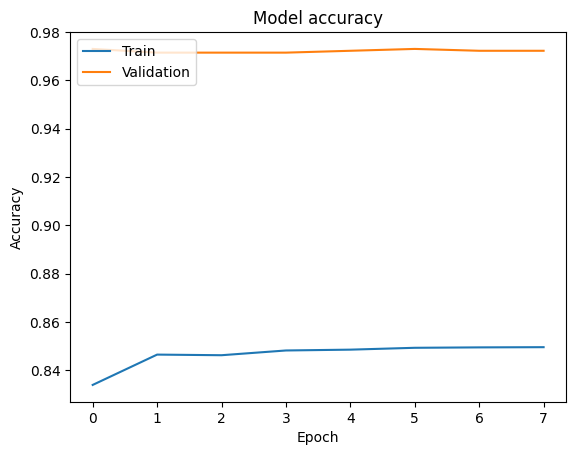

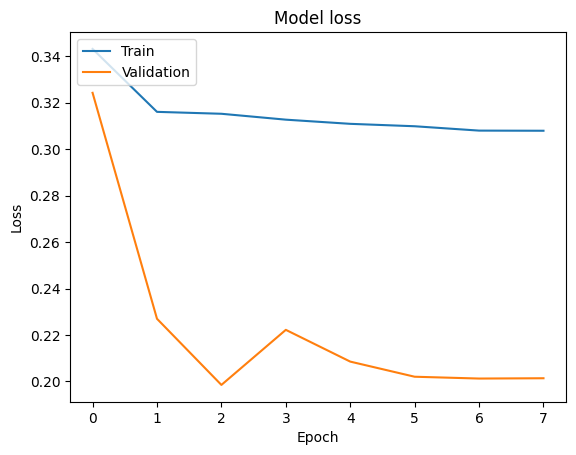

In [ ]:
# Plotting training & validation accuracy values
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

94/94 [==============================] - 1s 4ms/step


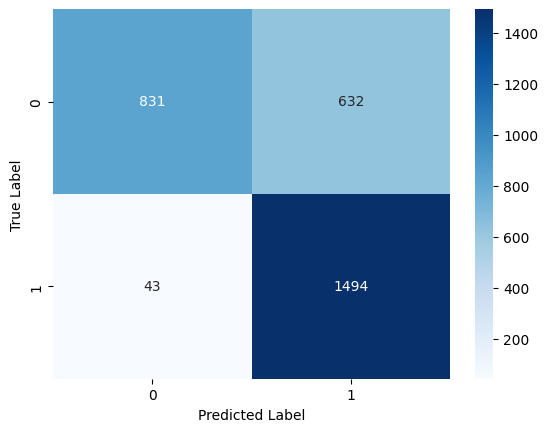

              precision    recall  f1-score   support

           0       0.95      0.57      0.71      1463
           1       0.70      0.97      0.82      1537

    accuracy                           0.78      3000
   macro avg       0.83      0.77      0.76      3000
weighted avg       0.82      0.78      0.76      3000



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict classes using the testing set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report, which includes precision, recall, and F1-score
report = classification_report(y_true, y_pred_classes)
print(report)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve, auc

# 假设 y_true 和 y_pred_classes 是您的真实标签和预测标签
# y_true = [Your true labels]
# y_pred_classes = [Your predicted labels]
y_pred_probs = model.predict(X_test)  # 模型预测的概率

# 由于 y_pred_probs 是一个形状为 (n_samples, 2) 的数组，我们需要选取代表正类概率的列
y_pred_probs = y_pred_probs[:, 1]  # 选择正类（索引为 1）的概率

# 计算度量指标
precision = precision_score(y_true, y_pred_classes)
recall = recall_score(y_true, y_pred_classes)
f1 = f1_score(y_true, y_pred_classes)
mcc = matthews_corrcoef(y_true, y_pred_classes)
accuracy = accuracy_score(y_true, y_pred_classes)
auc_score = roc_auc_score(y_true, y_pred_probs)  # 使用正类的概率计算 AUC

# 计算 PR AUC
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_probs)
pr_auc = auc(recall_vals, precision_vals)

# 打印度量指标
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print(f"PR AUC: {pr_auc:.4f}")




94/94 [==============================] - 1s 5ms/step
Precision: 0.7027
Recall: 0.9720
F1 Score: 0.8157
Matthews Correlation Coefficient: 0.5941
Accuracy: 0.7750
AUC: 0.9104
PR AUC: 0.9236


AUC: 0.9128


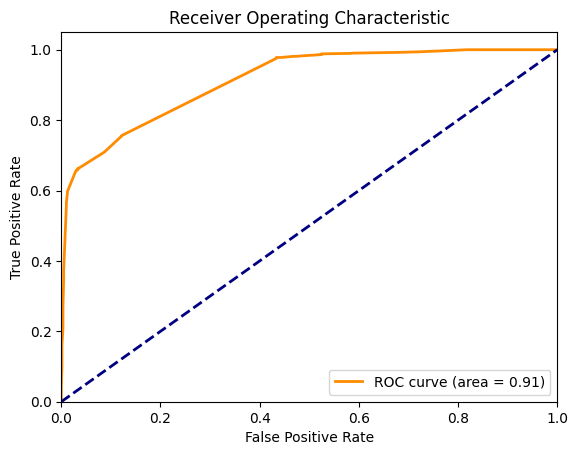

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# 假设 y_true 是您的真实标签和 y_pred_probs 是模型预测的概率
# 例如：y_true = [0, 1, 1, 0, 1] 和 y_pred_probs = [0.1, 0.9, 0.8, 0.3, 0.7]

# 计算AUC
auc = roc_auc_score(y_true, y_pred_probs)
print(f"AUC: {auc:.4f}")

# 计算ROC曲线的坐标
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# 绘制ROC曲线
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import ast
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from scipy.stats import entropy

# 加载数据
df = pd.read_csv('sampled_dataset.csv')
pool_df = pd.read_csv('remaining_dataset.csv')  # 加载数据池

# 将轨迹字符串转换为列表
df['trajectory'] = df['trajectory'].apply(ast.literal_eval)
pool_df['trajectory'] = pool_df['trajectory'].apply(ast.literal_eval)

# 固定序列长度 (早期窗口)
early_window = 5
X = pad_sequences(df['trajectory'], maxlen=early_window, padding='post')
y = to_categorical(df['Churn'].values)  # 转换为分类格式

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Active Learning 循环
n_iterations = 6
n_samples = 1000


for iteration in range(n_iterations):

    # 从数据池中计算不确定性并选择样本
    pool_X = pad_sequences(pool_df['trajectory'], maxlen=early_window, padding='post')
    pool_probabilities = model.predict(pool_X)
    pool_uncertainties = entropy(pool_probabilities.T)
    most_uncertain_indices = np.argsort(pool_uncertainties)[-n_samples:]
    sample_df = pool_df.iloc[most_uncertain_indices]
    pool_df = pool_df.drop(most_uncertain_indices).reset_index(drop=True)  # 重置索引

    # 准备新增数据
    X_new = pad_sequences(sample_df['trajectory'], maxlen=early_window, padding='post')
    y_new = to_categorical(sample_df['Churn'].values)

    # 更新训练集
    X_train = np.concatenate((X_train, X_new))
    y_train = np.concatenate((y_train, y_new))

    # 训练模型
    model = Sequential()
    model.add(Embedding(input_dim=200, output_dim=40, input_length=early_window))  # 增加 input_dim 和 output_dim
    model.add(LSTM(100, return_sequences=True))  # 增加 LSTM 单元
    model.add(Dropout(0.2))  # 添加 Dropout
    model.add(BatchNormalization())  # 添加 BatchNormalization
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(2, activation='softmax'))

    # 编译模型
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # 早停
    early_stopping = EarlyStopping(monitor='val_loss', patience=5)

    # 训练模型，包括早停回调
    history = model.fit(X_train, y_train, epochs=50, validation_split=0.1, callbacks=[early_stopping])

    # 测试模型
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f'Iteration {iteration+1}, Test Accuracy: {accuracy:.4f}')

12101/12101 [==============================] - 64s 5ms/step
Epoch 1/50
225/225 [==============================] - 8s 17ms/step - loss: 0.4000 - accuracy: 0.7853 - val_loss: 0.9312 - val_accuracy: 0.2512
Epoch 2/50
225/225 [==============================] - 3s 14ms/step - loss: 0.3658 - accuracy: 0.7997 - val_loss: 1.7919 - val_accuracy: 0.0225
Epoch 3/50
225/225 [==============================] - 3s 14ms/step - loss: 0.3609 - accuracy: 0.7944 - val_loss: 1.9965 - val_accuracy: 0.0225
Epoch 4/50
225/225 [==============================] - 3s 13ms/step - loss: 0.3586 - accuracy: 0.7997 - val_loss: 1.3182 - val_accuracy: 0.3375
Epoch 5/50
225/225 [==============================] - 3s 12ms/step - loss: 0.3571 - accuracy: 0.8017 - val_loss: 2.1691 - val_accuracy: 0.0275
Epoch 6/50
94/94 [==============================] - 2s 7ms/step - loss: 0.3563 - accuracy: 0.8070
Iteration 1, Test Accuracy: 0.8070
12070/12070 [==============================] - 63s 5ms/step
Epoch 1/50
254/254 [============

In [ ]:
X_train.shape

(17500, 5)

94/94 [==============================] - 1s 4ms/step


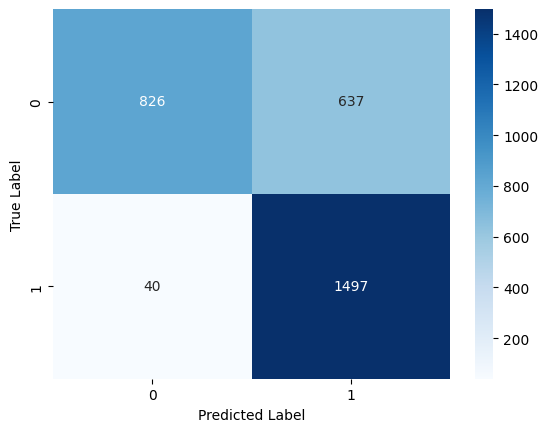

              precision    recall  f1-score   support

           0       0.95      0.56      0.71      1463
           1       0.70      0.97      0.82      1537

    accuracy                           0.77      3000
   macro avg       0.83      0.77      0.76      3000
weighted avg       0.82      0.77      0.76      3000

94/94 [==============================] - 0s 4ms/step
Precision: 0.7015
Recall: 0.9740
F1 Score: 0.8156
Matthews Correlation Coefficient: 0.5941
Accuracy: 0.7743
AUC: 0.9072
PR AUC: 0.9209


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict classes using the testing set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report, which includes precision, recall, and F1-score
report = classification_report(y_true, y_pred_classes)
print(report)


# 假设 y_true 和 y_pred_classes 是您的真实标签和预测标签
# y_true = [Your true labels]
# y_pred_classes = [Your predicted labels]
y_pred_probs = model.predict(X_test)  # 模型预测的概率

# 由于 y_pred_probs 是一个形状为 (n_samples, 2) 的数组，我们需要选取代表正类概率的列
y_pred_probs = y_pred_probs[:, 1]  # 选择正类（索引为 1）的概率

# 计算度量指标
precision = precision_score(y_true, y_pred_classes)
recall = recall_score(y_true, y_pred_classes)
f1 = f1_score(y_true, y_pred_classes)
mcc = matthews_corrcoef(y_true, y_pred_classes)
accuracy = accuracy_score(y_true, y_pred_classes)
auc_score = roc_auc_score(y_true, y_pred_probs)  # 使用正类的概率计算 AUC

# 计算 PR AUC
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_probs)
pr_auc = auc(recall_vals, precision_vals)

# 打印度量指标
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print(f"PR AUC: {pr_auc:.4f}")


In [ ]:
import pandas as pd
import numpy as np
import ast
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

def contains_sequence(trajectory, sequence, window_length):
    """检查序列中是否存在指定的数字组合，且只在指定的窗口长度内查找"""
    for i in range(min(len(trajectory) - len(sequence) + 1, window_length - len(sequence) + 1)):
        if trajectory[i:i + len(sequence)] == sequence:
            return True
    return False

# 加载数据
df = pd.read_csv('sampled_dataset.csv')
pool_df = pd.read_csv('remaining_dataset.csv')  # 加载数据池

# 将轨迹字符串转换为列表
df['trajectory'] = df['trajectory'].apply(ast.literal_eval)
pool_df['trajectory'] = pool_df['trajectory'].apply(ast.literal_eval)

# 固定序列长度 (早期窗口)
early_window = 5
X = pad_sequences(df['trajectory'], maxlen=early_window, padding='post')
y = to_categorical(df['Churn'].values)  # 转换为分类格式

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Active Learning 循环
n_iterations = 6
n_samples = 1000

for iteration in range(n_iterations):
    # 从数据池中筛选出前5个位置包含数字2的样本
    contains_2 = pool_df['trajectory'].apply(lambda x: 2 in x[:early_window])
    selected_samples_2 = pool_df[contains_2]

    # 如果样本数量不足，再筛选出包含序列 [2, 1] 的样本
    if len(selected_samples_2) < n_samples:
        contains_2_1 = pool_df['trajectory'].apply(lambda x: contains_sequence(x, [2, 1], early_window))
        selected_samples_2_1 = pool_df[contains_2_1]
        # 合并两组样本，但总数不超过n_samples
        selected_samples = pd.concat([selected_samples_2, selected_samples_2_1]).drop_duplicates().head(n_samples)
    else:
        selected_samples = selected_samples_2.head(n_samples)

    # 检查是否有选中的样本
    if selected_samples.empty:
        print("没有找到符合条件的样本。")
        continue  # 跳过当前迭代

    # 从数据池中移除已选样本
    pool_df = pool_df.drop(selected_samples.index).reset_index(drop=True)

    # 准备新增数据
    X_new = pad_sequences(selected_samples['trajectory'], maxlen=early_window, padding='post')
    y_new = to_categorical(selected_samples['Churn'].values)

    # 更新训练集
    X_train = np.concatenate((X_train, X_new))
    y_train = np.concatenate((y_train, y_new))

    # 训练模型
    model = Sequential([
        Embedding(input_dim=200, output_dim=40, input_length=early_window),
        LSTM(100, return_sequences=True),
        Dropout(0.2),
        BatchNormalization(),
        LSTM(50, return_sequences=False),
        Dense(2, activation='softmax')
    ])

    # 编译模型
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # 早停
    early_stopping = EarlyStopping(monitor='val_loss', patience=5)

    # 训练模型，包括早停回调
    history = model.fit(X_train, y_train, epochs=50, validation_split=0.1, callbacks=[early_stopping])

    # 测试模型
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f'Iteration {iteration+1}, Test Accuracy: {accuracy:.4f}')


Epoch 1/50
225/225 [==============================] - 9s 21ms/step - loss: 0.3850 - accuracy: 0.8053 - val_loss: 0.6552 - val_accuracy: 0.6587
Epoch 2/50
225/225 [==============================] - 3s 11ms/step - loss: 0.3471 - accuracy: 0.8271 - val_loss: 0.3359 - val_accuracy: 0.7950
Epoch 3/50
225/225 [==============================] - 3s 12ms/step - loss: 0.3435 - accuracy: 0.8272 - val_loss: 0.2573 - val_accuracy: 0.8487
Epoch 4/50
225/225 [==============================] - 3s 12ms/step - loss: 0.3418 - accuracy: 0.8285 - val_loss: 0.2044 - val_accuracy: 0.8875
Epoch 5/50
225/225 [==============================] - 3s 15ms/step - loss: 0.3373 - accuracy: 0.8286 - val_loss: 0.2331 - val_accuracy: 0.8863
Epoch 6/50
225/225 [==============================] - 3s 13ms/step - loss: 0.3351 - accuracy: 0.8276 - val_loss: 0.2378 - val_accuracy: 0.8487
Epoch 7/50
225/225 [==============================] - 3s 13ms/step - loss: 0.3353 - accuracy: 0.8281 - val_loss: 0.2015 - val_accuracy: 0.8875

94/94 [==============================] - 2s 6ms/step


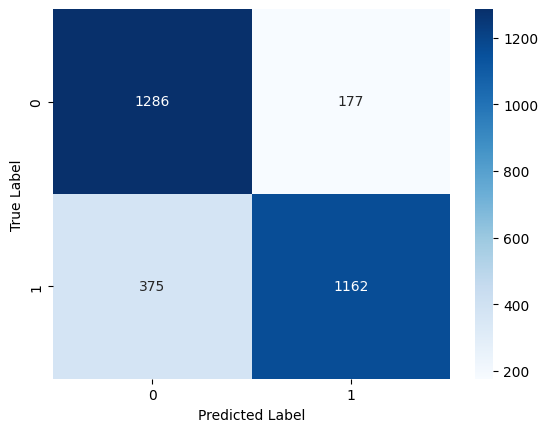

              precision    recall  f1-score   support

           0       0.77      0.88      0.82      1463
           1       0.87      0.76      0.81      1537

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000

94/94 [==============================] - 0s 4ms/step
Precision: 0.8678
Recall: 0.7560
F1 Score: 0.8081
Matthews Correlation Coefficient: 0.6385
Accuracy: 0.8160
AUC: 0.9127
PR AUC: 0.9261


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict classes using the testing set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report, which includes precision, recall, and F1-score
report = classification_report(y_true, y_pred_classes)
print(report)


# 假设 y_true 和 y_pred_classes 是您的真实标签和预测标签
# y_true = [Your true labels]
# y_pred_classes = [Your predicted labels]
y_pred_probs = model.predict(X_test)  # 模型预测的概率

# 由于 y_pred_probs 是一个形状为 (n_samples, 2) 的数组，我们需要选取代表正类概率的列
y_pred_probs = y_pred_probs[:, 1]  # 选择正类（索引为 1）的概率

# 计算度量指标
precision = precision_score(y_true, y_pred_classes)
recall = recall_score(y_true, y_pred_classes)
f1 = f1_score(y_true, y_pred_classes)
mcc = matthews_corrcoef(y_true, y_pred_classes)
accuracy = accuracy_score(y_true, y_pred_classes)
auc_score = roc_auc_score(y_true, y_pred_probs)  # 使用正类的概率计算 AUC

# 计算 PR AUC
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_probs)
pr_auc = auc(recall_vals, precision_vals)

# 打印度量指标
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print(f"PR AUC: {pr_auc:.4f}")


In [ ]:
import pandas as pd
import numpy as np
import ast
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from scipy.stats import entropy
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

def contains_sequence(trajectory, sequence):
    """检查序列中是否存在指定的数字组合"""
    for i in range(len(trajectory) - len(sequence) + 1):
        if trajectory[i:i + len(sequence)] == sequence:
            return True
    return False
# 加载数据
df = pd.read_csv('sampled_dataset.csv')
pool_df = pd.read_csv('remaining_dataset.csv')  # 加载数据池

# 将轨迹字符串转换为列表
df['trajectory'] = df['trajectory'].apply(ast.literal_eval)
pool_df['trajectory'] = pool_df['trajectory'].apply(ast.literal_eval)

# 固定序列长度 (早期窗口)
early_window = 5
X = pad_sequences(df['trajectory'], maxlen=early_window, padding='post')
y = to_categorical(df['Churn'].values)  # 转换为分类格式

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Active Learning 循环
n_iterations = 6
n_samples = 1000



for iteration in range(n_iterations):


   # 从数据池中筛选出包含数字 2 的样本
    contains_2 = pool_df['trajectory'].apply(lambda x: 3 in x[:5])
    selected_samples_2 = pool_df[contains_2]

    # 如果样本数量不足，再筛选出包含序列 [2, 1] 的样本
    if len(selected_samples_2) < n_samples:
        contains_2_1 = pool_df['trajectory'].apply(lambda x: contains_sequence(x[:5], [3, 1]))
        selected_samples_2_1 = pool_df[contains_2_1]
        # 合并两组样本，但总数不超过n_samples
        selected_samples = pd.concat([selected_samples_2, selected_samples_2_1]).head(n_samples)
    else:
        selected_samples = selected_samples_2.head(n_samples)
    # 检查是否有选中的样本
    if selected_samples.empty:
        print("没有找到符合条件的样本。")
        continue  # 跳过当前迭代

    # 从数据池中移除已选样本
    pool_df = pool_df.drop(selected_samples.index).reset_index(drop=True)

    # 准备新增数据
    X_new = pad_sequences(selected_samples['trajectory'], maxlen=early_window, padding='post')
    y_new = to_categorical(selected_samples['Churn'].values)

    # 更新训练集
    X_train = np.concatenate((X_train, X_new))
    y_train = np.concatenate((y_train, y_new))
    # 训练模型
     # 训练模型
    model = Sequential()
    model.add(Embedding(input_dim=200, output_dim=40, input_length=early_window))  # 增加 input_dim 和 output_dim
    model.add(LSTM(100, return_sequences=True))  # 增加 LSTM 单元
    model.add(Dropout(0.2))  # 添加 Dropout
    model.add(BatchNormalization())  # 添加 BatchNormalization
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(2, activation='softmax'))

    # 编译模型
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # 早停
    early_stopping = EarlyStopping(monitor='val_loss', patience=5)

    # 训练模型，包括早停回调
    history = model.fit(X_train, y_train, epochs=50, validation_split=0.1, callbacks=[early_stopping])
    # 测试模型
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f'Iteration {iteration+1}, Test Accuracy: {accuracy:.4f}')


Epoch 1/50
225/225 [==============================] - 8s 17ms/step - loss: 0.4004 - accuracy: 0.8003 - val_loss: 0.6876 - val_accuracy: 0.5350
Epoch 2/50
225/225 [==============================] - 4s 17ms/step - loss: 0.3680 - accuracy: 0.8171 - val_loss: 0.8445 - val_accuracy: 0.5188
Epoch 3/50
225/225 [==============================] - 3s 13ms/step - loss: 0.3638 - accuracy: 0.8181 - val_loss: 0.9255 - val_accuracy: 0.5575
Epoch 4/50
225/225 [==============================] - 3s 13ms/step - loss: 0.3596 - accuracy: 0.8204 - val_loss: 0.8664 - val_accuracy: 0.5863
Epoch 5/50
225/225 [==============================] - 3s 13ms/step - loss: 0.3613 - accuracy: 0.8189 - val_loss: 1.0057 - val_accuracy: 0.5738
Epoch 6/50
94/94 [==============================] - 1s 5ms/step - loss: 0.3685 - accuracy: 0.8103
Iteration 1, Test Accuracy: 0.8103
Epoch 1/50
254/254 [==============================] - 10s 17ms/step - loss: 0.4378 - accuracy: 0.7758 - val_loss: 0.5737 - val_accuracy: 0.7111
Epoch 2/

94/94 [==============================] - 1s 4ms/step


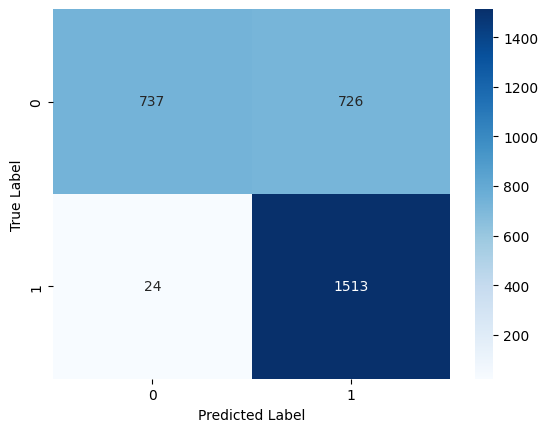

              precision    recall  f1-score   support

           0       0.97      0.50      0.66      1463
           1       0.68      0.98      0.80      1537

    accuracy                           0.75      3000
   macro avg       0.82      0.74      0.73      3000
weighted avg       0.82      0.75      0.73      3000

94/94 [==============================] - 1s 6ms/step
Precision: 0.6757
Recall: 0.9844
F1 Score: 0.8014
Matthews Correlation Coefficient: 0.5608
Accuracy: 0.7500
AUC: 0.9004
PR AUC: 0.9167


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict classes using the testing set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plotting the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification report, which includes precision, recall, and F1-score
report = classification_report(y_true, y_pred_classes)
print(report)


# 假设 y_true 和 y_pred_classes 是您的真实标签和预测标签
# y_true = [Your true labels]
# y_pred_classes = [Your predicted labels]
y_pred_probs = model.predict(X_test)  # 模型预测的概率

# 由于 y_pred_probs 是一个形状为 (n_samples, 2) 的数组，我们需要选取代表正类概率的列
y_pred_probs = y_pred_probs[:, 1]  # 选择正类（索引为 1）的概率

# 计算度量指标
precision = precision_score(y_true, y_pred_classes)
recall = recall_score(y_true, y_pred_classes)
f1 = f1_score(y_true, y_pred_classes)
mcc = matthews_corrcoef(y_true, y_pred_classes)
accuracy = accuracy_score(y_true, y_pred_classes)
auc_score = roc_auc_score(y_true, y_pred_probs)  # 使用正类的概率计算 AUC

# 计算 PR AUC
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_probs)
pr_auc = auc(recall_vals, precision_vals)

# 打印度量指标
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print(f"PR AUC: {pr_auc:.4f}")


In [ ]:
import pandas as pd
import numpy as np
import ast
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

def contains_sequence(trajectory, sequence, window_length):
    """检查序列中是否存在指定的数字组合，且只在指定的窗口长度内查找"""
    for i in range(min(len(trajectory) - len(sequence) + 1, window_length - len(sequence) + 1)):
        if trajectory[i:i + len(sequence)] == sequence:
            return True
    return False

# 加载数据
df = pd.read_csv('sampled_dataset.csv')
pool_df = pd.read_csv('remaining_dataset.csv')  # 加载数据池

# 将轨迹字符串转换为列表
df['trajectory'] = df['trajectory'].apply(ast.literal_eval)
pool_df['trajectory'] = pool_df['trajectory'].apply(ast.literal_eval)

# 固定序列长度 (早期窗口)
early_window = 5
X = pad_sequences(df['trajectory'], maxlen=early_window, padding='post')
y = to_categorical(df['Churn'].values)  # 转换为分类格式

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Active Learning 循环
n_iterations = 6
n_samples = 1000

for iteration in range(n_iterations):
    # 从数据池中筛选出前5个位置包含数字2的样本
    contains_2 = pool_df['trajectory'].apply(lambda x: 2 in x[:early_window])
    selected_samples_2 = pool_df[contains_2]

    # 如果样本数量不足，再筛选出包含序列 [2, 1] 的样本
    if len(selected_samples_2) < n_samples:
        contains_2_1 = pool_df['trajectory'].apply(lambda x: contains_sequence(x, [2, 1], early_window))
        selected_samples_2_1 = pool_df[contains_2_1]
        # 合并两组样本，但总数不超过n_samples
        selected_samples = pd.concat([selected_samples_2, selected_samples_2_1]).drop_duplicates().head(n_samples)
    else:
        selected_samples = selected_samples_2.head(n_samples)

    # 检查是否有选中的样本
    if selected_samples.empty:
        print("没有找到符合条件的样本。")
        continue  # 跳过当前迭代

    # 从数据池中移除已选样本
    pool_df = pool_df.drop(selected_samples.index).reset_index(drop=True)

    # 准备新增数据
    X_new = pad_sequences(selected_samples['trajectory'], maxlen=early_window, padding='post')
    y_new = to_categorical(selected_samples['Churn'].values)

    # 更新训练集
    X_train = np.concatenate((X_train, X_new))
    y_train = np.concatenate((y_train, y_new))

    # 训练模型
    model = Sequential([
        Embedding(input_dim=200, output_dim=40, input_length=early_window),
        LSTM(100, return_sequences=True),
        Dropout(0.2),
        BatchNormalization(),
        LSTM(50, return_sequences=False),
        Dense(2, activation='softmax')
    ])

    # 编译模型
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # 早停
    early_stopping = EarlyStopping(monitor='val_loss', patience=5)

    # 训练模型，包括早停回调
    history = model.fit(X_train, y_train, epochs=50, validation_split=0.1, callbacks=[early_stopping])

    # 测试模型
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f'Iteration {iteration+1}, Test Accuracy: {accuracy:.4f}')
